# Methodology 2 — Types of Operational Delays (Attribution Analysis)

In [111]:
# ── Setup (self-contained; mirrors Methodology 1 conventions) ───────────
import sys, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import KFold

SEED = 42; np.random.seed(SEED)
DISRUPTION_THRESHOLD = 5.0  
MIN_N = 30                   # minimum services per cause for a stable coefficient

df = pd.read_parquet("Data/final_data.parquet")

cause_cols = ['Cause Category_x','Cause Responsibility_x',
              'Cause Category_y','Cause Responsibility_y']
service_cols = ['Aggregated Delay','Aggregated NPS','Departure Delay','Arrival Delay',
                'metadata_route','route_type','equipment_type'] + cause_cols
service_cols = [c for c in service_cols if c in df.columns]

n_resp = df.groupby('service_id').size().rename('n_responses')
svc = pd.concat([df.groupby('service_id')[service_cols].first(), n_resp], axis=1).reset_index()
svc = svc[svc['n_responses'] >= 2]

# same outlier rules as Methodology 1
svc = svc[(svc['Aggregated Delay'] >= -60) & (svc['Aggregated Delay'] <= 600)]
print(f"Service-level sample: {len(svc):,}")

Service-level sample: 27,799


## 1. Mapping causes and internal vs external to number of services

**Reasoning (for the thesis).** A single disrupted journey can be caused by several factors simultaneously, recorded as  the cause fields.

1. **Union of departure and arrival causes.** 
2. **Multi-hot encoding, not single-label.** Because causes co-occur, each cause becomes its own binary dummy that can be 1 simultaneously with others. Each coefficient is then interpreted as the effect of that cause holding the other recorded causes constant
3. **Threshold-based activation.** A cause is only analytically meaningful if the passenger plausibly noticed a disruption, so dummies are activated only when the service breached the 5-minute punctuality margin.

In [112]:
def parse_pairs(row):
    """Return set of (category, responsibility) pairs from dep+arr fields."""
    pairs = set()
    for cat_c, resp_c in [('Cause Category_y','Cause Responsibility_y'),
                          ('Cause Category_x','Cause Responsibility_x')]:
        cat, resp = row.get(cat_c), row.get(resp_c)
        if pd.isna(cat) or cat in (None,'None',''): continue
        cats  = [c.strip() for c in str(cat).split('|')]
        resps = [r.strip() for r in str(resp).split('|')] if pd.notna(resp) else []
        for i, c in enumerate(cats):
            if not c or c=='None': continue
            r = resps[i] if i < len(resps) else (resps[0] if resps else 'Unknown')
            pairs.add((c, r))
    return pairs

svc['disrupted'] = svc['Aggregated Delay'] > DISRUPTION_THRESHOLD
svc['cause_pairs'] = svc.apply(lambda r: parse_pairs(r) if r['disrupted'] else set(), axis=1)

# frequency table + responsibility mapping
from collections import Counter, defaultdict
freq, resp_votes = Counter(), defaultdict(Counter)
for pairs in svc['cause_pairs']:
    for c, r in pairs:
        freq[c] += 1; resp_votes[c][r] += 1
resp_map = {c: resp_votes[c].most_common(1)[0][0] for c in freq}

freq_df = (pd.DataFrame({'n_services': pd.Series(freq),
                         'responsibility': pd.Series(resp_map)})
             .sort_values('n_services', ascending=False))
print(freq_df)

keep = freq_df[freq_df['n_services'] >= MIN_N].index.tolist()
print(f"\nCauses kept individually (n >= {MIN_N}): {len(keep)}; "
      f"grouped into Other_*: {len(freq_df)-len(keep)}")

def safe(name): return 'cause_' + re.sub(r'[^0-9a-zA-Z]+','_', name).strip('_')
dummy_names = {c: safe(c) for c in keep}

for c, col in dummy_names.items():
    svc[col] = svc['cause_pairs'].apply(lambda p: int(any(cc==c for cc,_ in p)))
svc['cause_Other_Internal'] = svc['cause_pairs'].apply(
    lambda p: int(any(cc not in keep and rr=='Internal' for cc,rr in p)))
svc['cause_Other_External'] = svc['cause_pairs'].apply(
    lambda p: int(any(cc not in keep and rr!='Internal' for cc,rr in p)))

cause_dummies = list(dummy_names.values()) + ['cause_Other_Internal','cause_Other_External']
resp_of_dummy = {dummy_names[c]: ('Internal' if resp_map[c]=='Internal' else 'External')
                 for c in keep}
resp_of_dummy['cause_Other_Internal']='Internal'; resp_of_dummy['cause_Other_External']='External'

print(f"\nBaseline (punctual, all dummies 0): {(~svc['disrupted']).sum():,} services")
print(f"Disrupted services: {svc['disrupted'].sum():,}")

                                                    n_services responsibility
I6 - Traffic Regulation                                  10346       External
I4 - Infrastructure Fault                                 1779       External
M1 - Reliability (Sets malfunctions/defects)              1661       Internal
S1 - Passengers                                           1192       Internal
I5 - Trains related incidents                             1041       External
I2 - People                                                702       External
S2 - Congestion                                            693       Internal
O1 - Driving                                               469       Internal
I3 - Infra Works                                           387       External
M3 - Lack of Available Trainsets                           361       Internal
I1 - Animals                                               359       External
Z1 - Weather related - Safety measures / Speed ...         328  

## 2. Descriptive analysis: average delay duration per cause


                                                         cause responsibility     n  mean_agg_delay  mean_dep_delay  mean_arr_delay  mean_agg_nps
                                                 S2_Congestion       Internal   693          106.11           31.88           74.23          0.14
                                                     I2_People       External   702           93.10           31.50           61.60          0.01
                                                    I1_Animals       External   359           91.49           28.39           63.11          0.04
                                A9_Additional_Operational_Stop       External    67           89.78           27.54           62.24          0.30
                      M1_Reliability_Sets_malfunctions_defects       Internal  1661           87.15           34.92           52.23          0.04
                              O4_OCC_Communication_issue_Error       Internal   212           81.60           32.52         

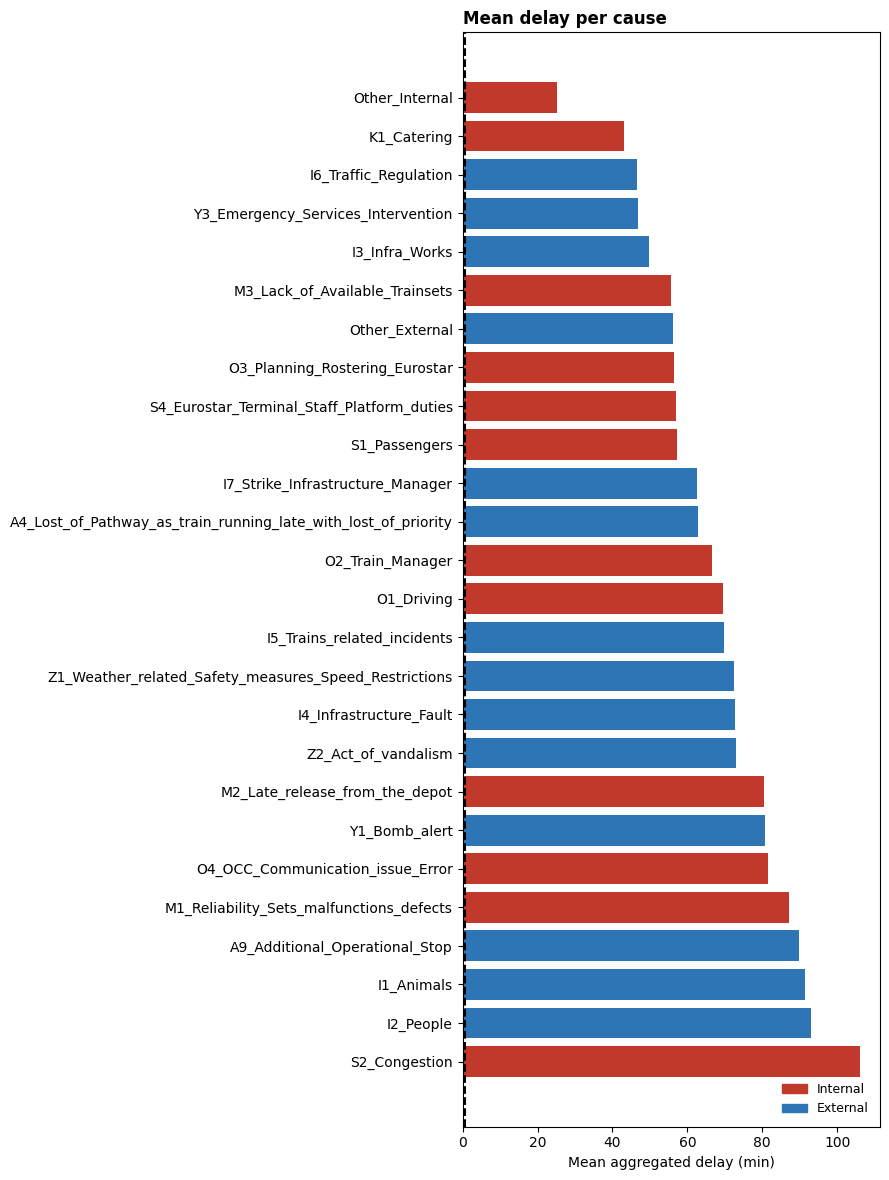

In [113]:
rows=[]
for col in cause_dummies:
    sub = svc[svc[col]==1]
    if len(sub)==0: continue
    rows.append({'cause': col.replace('cause_',''),
                 'responsibility': resp_of_dummy[col], 'n': len(sub),
                 'mean_agg_delay':  sub['Aggregated Delay'].mean(),
                 'mean_dep_delay':  sub['Departure Delay'].mean(),
                 'mean_arr_delay':  sub['Arrival Delay'].mean(),
                 'mean_agg_nps':    sub['Aggregated NPS'].mean()})
base = svc[~svc['disrupted']]
rows.append({'cause':'BASELINE (punctual)','responsibility':'-','n':len(base),
             'mean_agg_delay':base['Aggregated Delay'].mean(),
             'mean_dep_delay':base['Departure Delay'].mean(),
             'mean_arr_delay':base['Arrival Delay'].mean(),
             'mean_agg_nps':base['Aggregated NPS'].mean()})
desc = pd.DataFrame(rows).sort_values('mean_agg_delay', ascending=False)
print(desc.round(2).to_string(index=False))

plot_df = desc[desc['cause']!='BASELINE (punctual)']
colors = ['#c0392b' if r=='Internal' else '#2e75b6' for r in plot_df['responsibility']]
plt.figure(figsize=(9, 0.4*len(plot_df)+1.5))
plt.barh(plot_df['cause'], plot_df['mean_agg_delay'], color=colors)
plt.axvline(base['Aggregated Delay'].mean(), color='k', ls='--', label='punctual baseline')
plt.xlabel('Mean aggregated delay (min)'); plt.legend()
plt.title('Mean delay per cause',
             loc='left', fontsize=12, fontweight='bold')
plt.legend(handles=[mpatches.Patch(color='#c0392b', label='Internal'), mpatches.Patch(color='#2e75b6', label='External')], loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

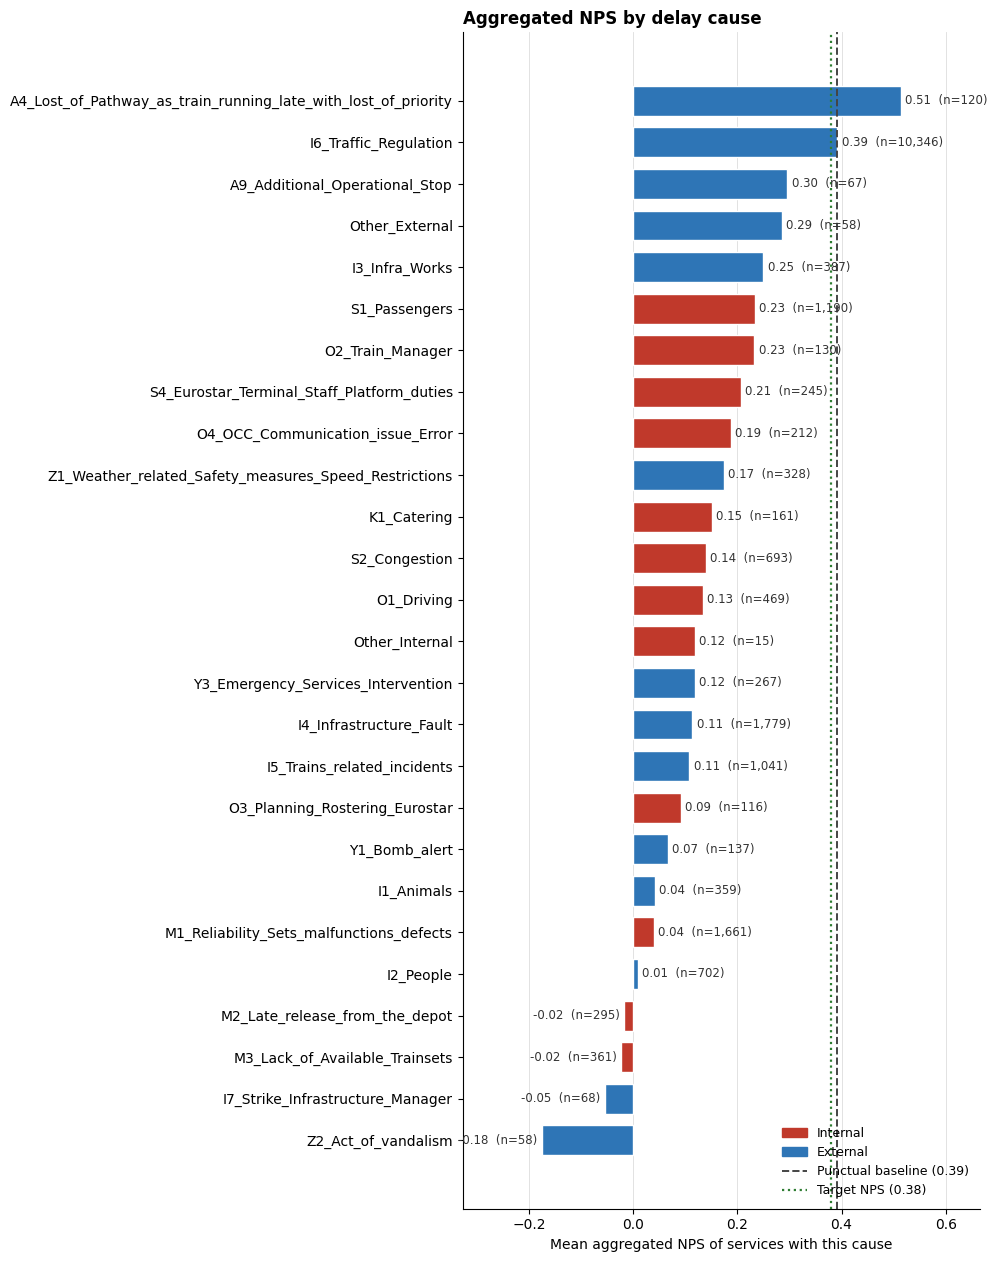

In [114]:
plot_df = (desc[desc['cause']!='BASELINE (punctual)']
           .sort_values('mean_agg_nps'))
base_nps = desc.loc[desc['cause']=='BASELINE (punctual)','mean_agg_nps'].iloc[0]
colors = ['#c0392b' if r=='Internal' else '#2e75b6' for r in plot_df['responsibility']]

fig, ax = plt.subplots(figsize=(10, 0.42*len(plot_df)+1.8))
bars = ax.barh(plot_df['cause'], plot_df['mean_agg_nps'], color=colors,
               edgecolor='white', height=0.72)
ax.axvline(base_nps, color='#444444', ls='--', lw=1.4,
           label=f'Punctual baseline ({base_nps:.2f})')
ax.axvline(0.38, color='#2e7d32', ls=':', lw=1.6, label='Target NPS (0.38)')
for bar, v, n in zip(bars, plot_df['mean_agg_nps'], plot_df['n']):
    ax.text(v + (0.008 if v>=0 else -0.008), bar.get_y()+bar.get_height()/2,
            f'{v:.2f}  (n={n:,})', va='center',
            ha='left' if v>=0 else 'right', fontsize=8.5, color='#333333')
vmin, vmax = plot_df['mean_agg_nps'].min(), plot_df['mean_agg_nps'].max()
pad = 0.22*(vmax - vmin)
ax.set_xlim(vmin - pad, vmax + pad)   # room so labels of extreme bars are not clipped
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', color='#dddddd', lw=0.6); ax.set_axisbelow(True)
ax.set_xlabel('Mean aggregated NPS of services with this cause')
ax.set_title('Aggregated NPS by delay cause',
             loc='left', fontsize=12, fontweight='bold')
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color='#c0392b', label='Internal'),
                   mpatches.Patch(color='#2e75b6', label='External'),
                   *ax.get_legend_handles_labels()[0]],
          loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Regression specifications

**Estimator: WLS with weights = n_responses, HC3 robust SEs** — identical to Methodology 1 for the same reasons (Var(NPS̄ₛ) ∝ 1/nₛ).

Three specifications, each answering a different question:

| Spec | Equation | Question answered |
|---|---|---|
| **A — total effect** | `agg_nps ~ cause dummies` | How much lower is NPS on journeys with this cause vs. the punctual baseline. |
| **B — net of duration** | `agg_nps ~ agg_delay + cause dummies` | The Weiner test holding the delay length fixed, that bases this on attribution theory. Specificiation (Spec) B isolates this judgement channel from the mechanical duration channel. |
| **C — robustness** | Spec B + route dummies | Confirms cause coefficients are not artefacts of causes clustering on particular routes with different baseline NPS. |

In [115]:
m2 = svc.dropna(subset=['Aggregated NPS','Aggregated Delay','n_responses']).copy()
y, w = m2['Aggregated NPS'], m2['n_responses']

XA = sm.add_constant(m2[cause_dummies])
XB = sm.add_constant(m2[['Aggregated Delay'] + cause_dummies])
routes = pd.get_dummies(m2['route_type'], prefix='route', drop_first=True).astype(float)
XC = sm.add_constant(pd.concat([m2[['Aggregated Delay']+cause_dummies], routes], axis=1))

specA = sm.WLS(y, XA, weights=w).fit(cov_type='HC3')
specB = sm.WLS(y, XB, weights=w).fit(cov_type='HC3')
specC = sm.WLS(y, XC, weights=w).fit(cov_type='HC3')

comp = pd.DataFrame({'A_total': specA.params, 'B_net_of_duration': specB.params,
                     'C_with_routes': specC.params,
                     'B_pvalue': specB.pvalues}).loc[['const','Aggregated Delay']+cause_dummies
                                                     if 'Aggregated Delay' in specB.params
                                                     else ['const']+cause_dummies]
print(comp.round(4).to_string())
print(f"\nR2:  A={specA.rsquared:.4f}  B={specB.rsquared:.4f}  C={specC.rsquared:.4f}")

                                                                      A_total  B_net_of_duration  C_with_routes  B_pvalue
const                                                                  0.3349             0.4152         0.6993    0.0000
Aggregated Delay                                                          NaN            -0.0023        -0.0042    0.0000
cause_I6_Traffic_Regulation                                            0.0982             0.1290         0.0448    0.0000
cause_I4_Infrastructure_Fault                                         -0.2277            -0.1284        -0.0859    0.0000
cause_M1_Reliability_Sets_malfunctions_defects                        -0.3004            -0.1593        -0.1290    0.0000
cause_S1_Passengers                                                   -0.0837            -0.0317        -0.0752    0.0125
cause_I5_Trains_related_incidents                                     -0.1776            -0.0982        -0.0824    0.0000
cause_I2_People         

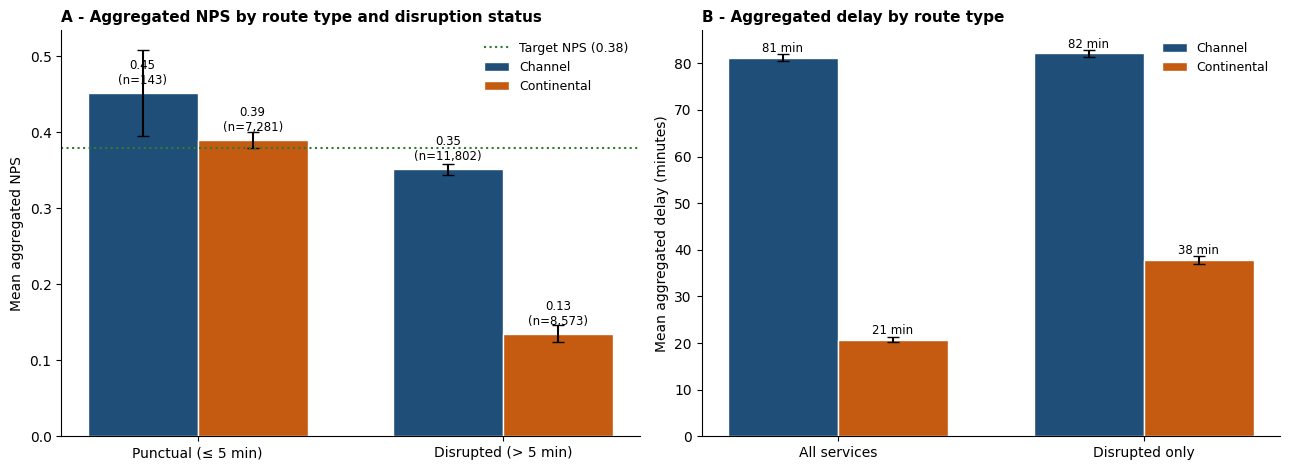

                       mean_nps  mean_delay      n
route_type  disrupted                             
Channel     False         0.452       1.935    143
            True          0.351      82.198  11802
Continental False         0.390       0.644   7281
            True          0.135      37.828   8573

Disrupted share: {'Channel': 0.988, 'Continental': 0.541}


In [116]:
import matplotlib.patches as mpatches

rt_colors = {'Channel': '#1f4e79', 'Continental': '#c55a11'}
route_types = [r for r in ['Channel', 'Continental'] if r in m2['route_type'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# mean aggregated NPS: punctual vs disrupted, per route type
x = np.arange(2); wdt = 0.36
for i, rt in enumerate(route_types):
    sub = m2[m2['route_type'] == rt]
    grp = [sub[~sub['disrupted']], sub[sub['disrupted']]]
    means = [g['Aggregated NPS'].mean() for g in grp]
    errs  = [1.96 * g['Aggregated NPS'].sem() for g in grp]
    ns    = [len(g) for g in grp]
    off = (i - 0.5) * wdt
    bars = axes[0].bar(x + off, means, wdt, yerr=errs, capsize=4,
                       color=rt_colors[rt], alpha=1 - 0.45*i if False else 1,
                       edgecolor='white', label=rt)
    for b, v, n_ in zip(bars, means, ns):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.012,
                     f'{v:.2f}\n(n={n_:,})', ha='center', fontsize=8.5)
axes[0].axhline(0.38, color='#2e7d32', ls=':', lw=1.5, label='Target NPS (0.38)')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Punctual (≤ 5 min)', 'Disrupted (> 5 min)'])
axes[0].set_ylabel('Mean aggregated NPS')
axes[0].set_title('A - Aggregated NPS by route type and disruption status',
                  loc='left', fontweight='bold', fontsize=11)
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# mean aggregated delay per route type, all vs disrupted-only
x2 = np.arange(2)
for i, rt in enumerate(route_types):
    sub = m2[m2['route_type'] == rt]
    grp = [sub, sub[sub['disrupted']]]
    means = [g['Aggregated Delay'].mean() for g in grp]
    errs  = [1.96 * g['Aggregated Delay'].sem() for g in grp]
    off = (i - 0.5) * wdt
    bars = axes[1].bar(x2 + off, means, wdt, yerr=errs, capsize=4,
                       color=rt_colors[rt], edgecolor='white', label=rt)
    for b, v in zip(bars, means):
        axes[1].text(b.get_x() + b.get_width()/2, v + 1.2, f'{v:.0f} min',
                     ha='center', fontsize=8.5)
axes[1].set_xticks(x2); axes[1].set_xticklabels(['All services', 'Disrupted only'])
axes[1].set_ylabel('Mean aggregated delay (minutes)')
axes[1].set_title('B - Aggregated delay by route type',
                  loc='left', fontweight='bold', fontsize=11)
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print(m2.groupby(['route_type', 'disrupted'])
        .agg(mean_nps=('Aggregated NPS', 'mean'),
             mean_delay=('Aggregated Delay', 'mean'),
             n=('Aggregated NPS', 'size')).round(3))
print(f"\nDisrupted share: "
      f"{m2.groupby('route_type')['disrupted'].mean().round(3).to_dict()}")

## 4. Attribution theory (Weiner Test): Internal vs External coefficients

### What is the Weiner contrast test?

Bernard Weiner's (1985) attribution theory holds that when a service failure occurs, customers do not respond only to the *magnitude* of the failure — they also form causal attributions that shape how much blame they assign to the provider. The dimension most relevant here is **locus of causality**: was the failure caused by the provider (internal) or by forces outside the provider's control (external)?

Attribution theory predicts that an identically long delay will produce a more negative NPS reaction when passengers attribute it to an internal cause (e.g. a train malfunction, a staffing error) than to an external cause (e.g. weather, third-party infrastructure). Internal failures invite blame and undermine trust; external failures are more readily forgiven.

**The contrast test** operationalises this as a single linear hypothesis on the regression coefficients. After holding delay duration constant in Spec B, each cause dummy has a coefficient β_c capturing the NPS difference attributable purely to the cause label — not to how long the delay was. The Weiner contrast is:

> **H₀: mean(β_Internal) − mean(β_External) = 0**

tested as a Wald / t-test using the HC3 covariance matrix, with contrast vector **L** where L_c = +1/n_internal for internal causes, L_c = −1/n_external for external causes, and 0 otherwise. Rejecting H₀ means internal causes produce a systematically more negative NPS reaction than external ones *beyond* what delay duration alone would predict — confirming the attribution hypothesis.

**The mean of the Internal cause coefficients being more negative than the mean of the External ones** is the directional prediction under test.

### What "holding delay duration constant" precisely means — and at which delay level

In the linear Spec B, `agg_nps = α + δ·agg_delay + Σ βc·Dc`, each cause coefficient βc is a parallel intercept shift: for any fixed delay value d, the model-implied difference E[NPS | cause c, delay = d] − E[NPS | no cause, delay = d] equals βc. The comparison therefore holds delay at the same value for both journeys being compared.

### Why the compensation regime threatens that assumption

Eurostar's compensation policy is triggered at delay thresholds. If compensation partially restores satisfaction, the true NPS–delay relationship is not linear.

### The fix implemented below — delay severity bands + explicit compensation control

**Spec B-bands** replaces the linear delay term with severity-band dummies with boundaries aligned to the punctuality margin and the compensation thresholds: (5–15], (15–30], (30–60], (60+] minutes, with ≤ 5 min (punctual) as the reference. A step function imposes no functional form on the delay–NPS relationship, so whatever shape compensation induces is absorbed by the band coefficients, and each cause coefficient is net of the entire empirical delay profile rather than net of a straight line.

In [117]:
internal = [c for c in cause_dummies if resp_of_dummy[c]=='Internal']
external = [c for c in cause_dummies if resp_of_dummy[c]=='External']
print(f"Internal causes ({len(internal)}): {internal}")
print(f"External causes ({len(external)}): {external}\n")

L = pd.Series(0.0, index=specB.params.index)
L[internal] =  1.0/len(internal)
L[external] = -1.0/len(external)
contrast = specB.t_test(L.values)
print("H0: mean(beta_Internal) - mean(beta_External) = 0")
print(contrast)

grp = pd.DataFrame({'coef_B': specB.params[cause_dummies],
                    'resp': pd.Series(resp_of_dummy)})
print("\nGroup means of cause coefficients (Spec B):")
print(grp.groupby('resp')['coef_B'].agg(['mean','count']).round(4))

Internal causes (12): ['cause_M1_Reliability_Sets_malfunctions_defects', 'cause_S1_Passengers', 'cause_S2_Congestion', 'cause_O1_Driving', 'cause_M3_Lack_of_Available_Trainsets', 'cause_M2_Late_release_from_the_depot', 'cause_S4_Eurostar_Terminal_Staff_Platform_duties', 'cause_O4_OCC_Communication_issue_Error', 'cause_K1_Catering', 'cause_O2_Train_Manager', 'cause_O3_Planning_Rostering_Eurostar', 'cause_Other_Internal']
External causes (14): ['cause_I6_Traffic_Regulation', 'cause_I4_Infrastructure_Fault', 'cause_I5_Trains_related_incidents', 'cause_I2_People', 'cause_I3_Infra_Works', 'cause_I1_Animals', 'cause_Z1_Weather_related_Safety_measures_Speed_Restrictions', 'cause_Y3_Emergency_Services_Intervention', 'cause_Y1_Bomb_alert', 'cause_A4_Lost_of_Pathway_as_train_running_late_with_lost_of_priority', 'cause_I7_Strike_Infrastructure_Manager', 'cause_A9_Additional_Operational_Stop', 'cause_Z2_Act_of_vandalism', 'cause_Other_External']

H0: mean(beta_Internal) - mean(beta_External) = 0
 

               mean    sem  count
band                             
punctual_ref  0.391  0.005   7424
b5_15         0.368  0.008   3308
b15_30        0.242  0.010   2074
b30_60        0.135  0.010   2378
b60_plus      0.259  0.004  12615


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/1626991238.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_stats = m2.groupby('band')['Aggregated NPS'].agg(['mean','sem','count'])


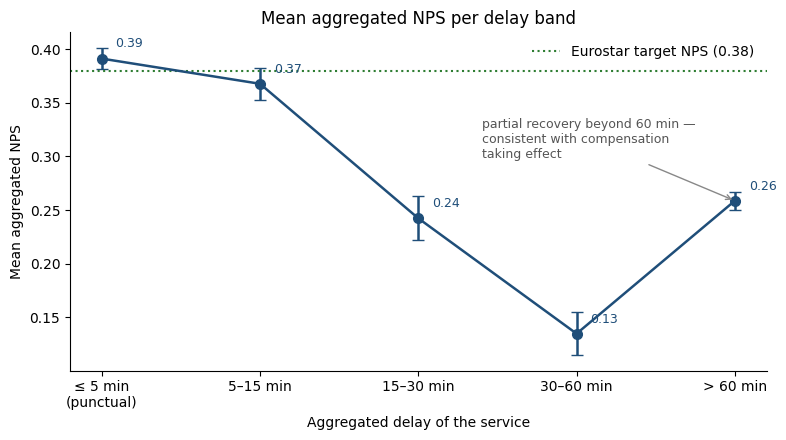


Cause coefficients under the three duration treatments:
                                                                      B_linear  B_bands  B_bands_comp
cause_I6_Traffic_Regulation                                             0.1290   0.1917        0.1624
cause_I4_Infrastructure_Fault                                          -0.1284  -0.1373       -0.0409
cause_M1_Reliability_Sets_malfunctions_defects                         -0.1593  -0.2088       -0.1313
cause_S1_Passengers                                                    -0.0317  -0.0084       -0.0182
cause_I5_Trains_related_incidents                                      -0.0982  -0.0870       -0.0375
cause_I2_People                                                        -0.1798  -0.2420       -0.1138
cause_S2_Congestion                                                    -0.0375  -0.1197       -0.0871
cause_O1_Driving                                                       -0.0625  -0.0532       -0.0405
cause_I3_Infra_Works     

/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/1626991238.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Weiner contrast [{name:22s}]: diff = {float(t.effect):.4f}, "
/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/1626991238.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Weiner contrast [{name:22s}]: diff = {float(t.effect):.4f}, "
/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/1626991238.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array bef

In [118]:
# Spec B-bands: compensation
comp_share = (df.groupby('service_id')['metadata_compensation_flag'].mean())
m2['comp_share'] = m2['service_id'].map(comp_share).fillna(0).astype(float)

m2['band'] = pd.cut(m2['Aggregated Delay'],
                    bins=[-np.inf, 5, 15, 30, 60, np.inf],
                    labels=['punctual_ref','b5_15','b15_30','b30_60','b60_plus'])
band_d = (pd.get_dummies(m2['band'], prefix='band')
            .drop(columns=['band_punctual_ref']).astype(float))

XB2 = sm.add_constant(pd.concat([band_d, m2[cause_dummies].astype(float)], axis=1))
XB3 = sm.add_constant(pd.concat([band_d, m2[['comp_share']],
                                 m2[cause_dummies].astype(float)], axis=1))
assert XB2.notna().all().all() and np.isfinite(XB2.to_numpy()).all(), "NaN/inf in XB2"
assert XB3.notna().all().all() and np.isfinite(XB3.to_numpy()).all(), "NaN/inf in XB3"

band_stats = m2.groupby('band')['Aggregated NPS'].agg(['mean','sem','count'])
print(band_stats.round(3))

band_labels = ['≤ 5 min\n(punctual)', '5–15 min', '15–30 min', '30–60 min', '> 60 min']
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(range(len(band_stats)), band_stats['mean'], yerr=1.96*band_stats['sem'],
            fmt='o-', capsize=4, color='#1f4e79', lw=1.8, markersize=7)
for i_, (mu, n_) in enumerate(zip(band_stats['mean'], band_stats['count'])):
    ax.annotate(f'{mu:.2f}', (i_, mu), textcoords='offset points',
                xytext=(10, 8), fontsize=9, color='#1f4e79')
ax.axhline(0.38, color='#2e7d32', ls=':', lw=1.5, label='Eurostar target NPS (0.38)')
ax.annotate('partial recovery beyond 60 min —\nconsistent with compensation\ntaking effect',
            xy=(4, band_stats['mean'].iloc[4]), xytext=(2.4, band_stats['mean'].iloc[4]+0.04),
            fontsize=9, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#888888'))
ax.set_xticks(range(len(band_labels))); ax.set_xticklabels(band_labels)
ax.set_xlabel('Aggregated delay of the service')
ax.set_ylabel('Mean aggregated NPS')
ax.set_title('Mean aggregated NPS per delay band')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

specB_bands = sm.WLS(m2['Aggregated NPS'], XB2, weights=m2['n_responses']).fit(cov_type='HC3')
specB_comp  = sm.WLS(m2['Aggregated NPS'], XB3, weights=m2['n_responses']).fit(cov_type='HC3')

cmp = pd.DataFrame({'B_linear': specB.params.reindex(cause_dummies),
                    'B_bands':  specB_bands.params.reindex(cause_dummies),
                    'B_bands_comp': specB_comp.params.reindex(cause_dummies)})
print("\nCause coefficients under the three duration treatments:")
print(cmp.round(4).to_string())

print("\nBand coefficients (NPS vs punctual reference, common across causes):")
print(specB_bands.params.reindex(band_d.columns).round(4).to_string())

for name, fit in [('linear delay', specB), ('severity bands', specB_bands),
                  ('bands + compensation', specB_comp)]:
    L = pd.Series(0.0, index=fit.params.index)
    L[internal] = 1.0/len(internal); L[external] = -1.0/len(external)
    t = fit.t_test(L.values)
    print(f"Weiner contrast [{name:22s}]: diff = {float(t.effect):.4f}, "
          f"p = {float(t.pvalue):.4g}")

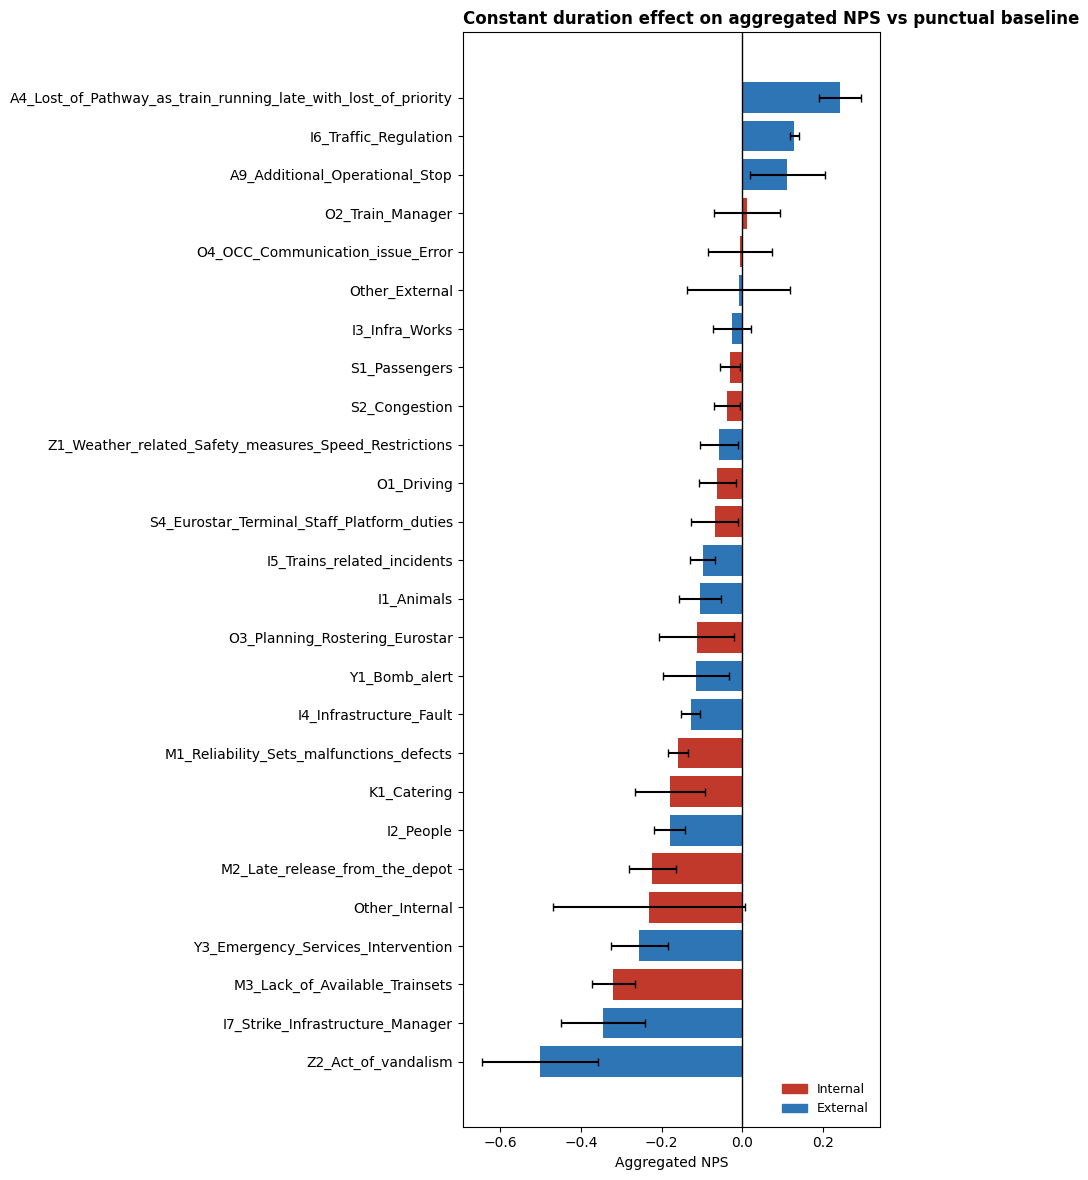

In [119]:
ci = specB.conf_int().loc[cause_dummies]
ord_ = specB.params[cause_dummies].sort_values().index
colors = ['#c0392b' if resp_of_dummy[c]=='Internal' else '#2e75b6' for c in ord_]
plt.figure(figsize=(9, 0.4*len(ord_)+1.5))
plt.barh([c.replace('cause_','') for c in ord_], specB.params[ord_],
         xerr=[specB.params[ord_]-ci.loc[ord_,0], ci.loc[ord_,1]-specB.params[ord_]],
         color=colors, capsize=3)
plt.axvline(0, color='k', lw=1)
plt.xlabel('Aggregated NPS')
plt.title('Constant duration effect on aggregated NPS vs punctual baseline',
             loc='left', fontsize=12, fontweight='bold')
plt.legend(handles=[mpatches.Patch(color='#c0392b', label='Internal'), mpatches.Patch(color='#2e75b6', label='External')], loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Per-route-type analysis (Channel vs Continental)

**Reasoning.** The two halves of the network differ structurally: Channel services pass border control and the tunnel with UK-bound passenger profiles, while Continental services operate the former-Thalys network with different infrastructure managers and passenger expectations.

### How to read the Spec B-bands coefficients in this section

The within-route-type model is `agg_nps = α + Σ δb·Band_b + Σ βc·Cause_c`, estimated separately for Channel and for Continental services. Two sets of coefficients appear, with distinct meanings:

- **Band coefficients (δb)** — the average NPS difference between services whose aggregated delay falls in band b and punctual services of the same route type, regardless of cause. These trace the empirical delay–NPS profile within the route type, including any compensation-driven recovery.
- **Cause coefficients (βc)** —  βc is the average NPS difference between a service with cause c and a service of the same route type, in the same delay severity band, with the same other recorded causes, attributable purely to the cause label itself.

In [120]:
route_results={}
for rt, sub in m2.groupby('route_type'):
    active = [c for c in cause_dummies if sub[c].sum() >= 15]
    if len(active)==0 or len(sub) < 200: continue
    bd = pd.get_dummies(sub['band'], prefix='band')
    bd = bd.drop(columns=[c for c in ['band_punctual_ref'] if c in bd]).astype(float)
    Xr = sm.add_constant(pd.concat([bd, sub[active]], axis=1))
    fit = sm.WLS(sub['Aggregated NPS'], Xr, weights=sub['n_responses']).fit(cov_type='HC3')
    route_results[rt] = fit.params.reindex(active)
    # Weiner contrast within route type
    ints = [c for c in active if resp_of_dummy[c]=='Internal']
    exts = [c for c in active if resp_of_dummy[c]=='External']
    if ints and exts:
        L = pd.Series(0.0, index=fit.params.index)
        L[ints] = 1.0/len(ints); L[exts] = -1.0/len(exts)
        t = fit.t_test(L.values)
        print(f"{rt}: n={len(sub):,} | Weiner contrast diff={float(t.effect):.4f}, "
              f"p={float(t.pvalue):.4g}")
route_tab = pd.DataFrame(route_results)
print("\nCause coefficients by route type (Spec B-bands within group):")
print(route_tab.round(4).to_string())

Channel: n=11,945 | Weiner contrast diff=-0.0788, p=0.0004215
Continental: n=15,854 | Weiner contrast diff=-0.0119, p=0.5623

Cause coefficients by route type (Spec B-bands within group):
                                                                      Channel  Continental
cause_A4_Lost_of_Pathway_as_train_running_late_with_lost_of_priority   0.3060          NaN
cause_A9_Additional_Operational_Stop                                   0.1330          NaN
cause_I1_Animals                                                       0.0284      -0.0216
cause_I2_People                                                       -0.0999      -0.0420
cause_I3_Infra_Works                                                   0.1117       0.0346
cause_I4_Infrastructure_Fault                                          0.0398      -0.0489
cause_I5_Trains_related_incidents                                      0.0924      -0.0422
cause_I6_Traffic_Regulation                                            0.2972       

/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/3831964915.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{rt}: n={len(sub):,} | Weiner contrast diff={float(t.effect):.4f}, "
/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/3831964915.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{rt}: n={len(sub):,} | Weiner contrast diff={float(t.effect):.4f}, "


Causes on both networks: 19 | network-specific: 7


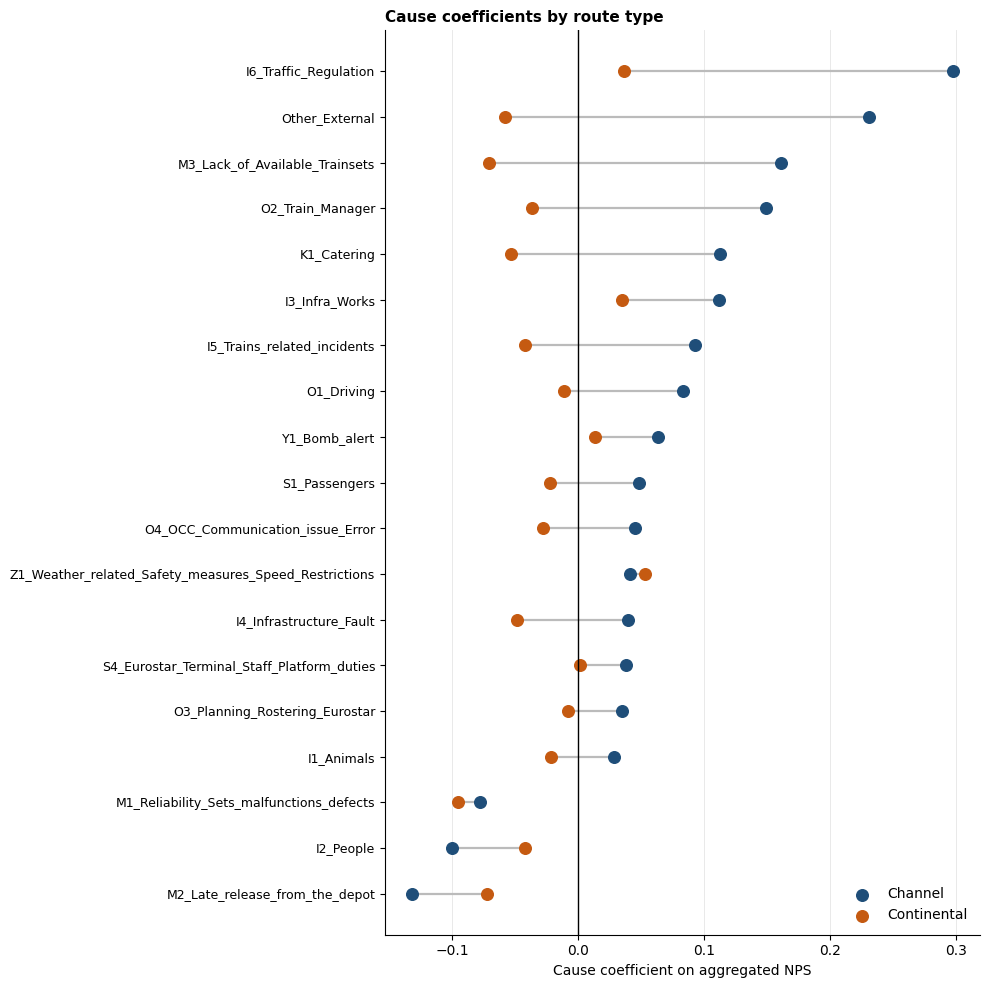

In [121]:
rt_colors = {'Channel': '#1f4e79', 'Continental': '#c55a11'}

both = route_tab.dropna()                      # causes estimable on BOTH networks
only = route_tab[route_tab.isna().any(axis=1)] # network-specific causes (report in text)
print(f"Causes on both networks: {len(both)} | network-specific: {len(only)}")

both = both.assign(gap=both['Channel'] - both['Continental']).sort_values('Channel')
labels = [c.replace('cause_', '') for c in both.index]
ypos = np.arange(len(both))

fig, ax = plt.subplots(figsize=(10, 0.42*len(both) + 2))
for y, (_, row) in zip(ypos, both.iterrows()):
    ax.plot([row['Continental'], row['Channel']], [y, y],
            color='#bbbbbb', lw=1.6, zorder=1)
ax.scatter(both['Channel'], ypos, s=70, color=rt_colors['Channel'],
           zorder=2, label='Channel')
ax.scatter(both['Continental'], ypos, s=70, color=rt_colors['Continental'],
           zorder=2, label='Continental')
ax.axvline(0, color='k', lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Cause coefficient on aggregated NPS')
ax.set_title('Cause coefficients by route type',
             loc='left', fontweight='bold', fontsize=11)
ax.grid(axis='x', color='#e5e5e5', lw=0.6); ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Evaluation

**Joint F-test.** Comparing Spec B against a duration-only model tests whether the cause dummies are jointly significant. A significant F confirms the central premise of Methodology 2.

**5-fold cross-validation** (same protocol and seed as Methodology 1, weighted R²) quantifies out-of-sample explanatory power and by comparing the CV-R² of the duration-only model with Spec B 
**Residual diagnostics** (Breusch–Pagan, residual-vs-fitted) verify the WLS specification.

In [122]:
# (a) cause dummies jointly zero, within Spec B
Rb = np.zeros((len(cause_dummies), len(specB.params)))
for i, c in enumerate(cause_dummies):
    Rb[i, list(specB.params.index).index(c)] = 1
print("Spec B — causes jointly zero:")
print(specB.f_test(Rb))

# (b) route_type dummies jointly zero, within Spec C
route_terms = [c for c in specC.params.index if c.startswith('route_')]
Rc = np.zeros((len(route_terms), len(specC.params)))
for i, c in enumerate(route_terms):
    Rc[i, list(specC.params.index).index(c)] = 1
print("\nSpec C — route type jointly zero (beyond duration + causes):")
print(specC.f_test(Rc))

# 5-fold CV
def weighted_r2(y, yhat, w):
    ybar = np.average(y, weights=w)
    return 1 - np.sum(w*(y-yhat)**2) / np.sum(w*(y-ybar)**2)

route_d_full = pd.get_dummies(m2['route_type'], prefix='route',
                              drop_first=True).astype(float)
route_cols = list(route_d_full.columns)
m2_cv = pd.concat([m2, route_d_full], axis=1)

specs = {
    'duration_only': ['Aggregated Delay'],
    'specB_causes':  ['Aggregated Delay'] + cause_dummies,
    'specC_+route':  ['Aggregated Delay'] + cause_dummies + route_cols,
}

kf = KFold(5, shuffle=True, random_state=SEED)
cv = {k: [] for k in specs}
for tr, te in kf.split(m2_cv):
    trd, ted = m2_cv.iloc[tr], m2_cv.iloc[te]
    for name, cols in specs.items():
        f = sm.WLS(trd['Aggregated NPS'], sm.add_constant(trd[cols]),
                   weights=trd['n_responses']).fit()
        pred = f.predict(sm.add_constant(ted[cols]))
        cv[name].append(weighted_r2(ted['Aggregated NPS'], pred, ted['n_responses']))

print("\n5-fold CV weighted R2 (out-of-sample):")
prev = None
for k, v in cv.items():
    mean = np.mean(v)
    delta = f"  (+{mean-prev:.4f})" if prev is not None else ""
    print(f"  {k:15s}: {mean:.4f} ± {np.std(v):.4f}{delta}")
    prev = mean



/Users/manuelbraun/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/manuelbraun/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/manuelbraun/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


Spec B — causes jointly zero:
<F test: F=73.3592761018072, p=0.0, df_denom=2.78e+04, df_num=26>

Spec C — route type jointly zero (beyond duration + causes):
<F test: F=2234.8598422879572, p=0.0, df_denom=2.78e+04, df_num=1>

5-fold CV weighted R2 (out-of-sample):
  duration_only  : 0.1216 ± 0.0181
  specB_causes   : 0.1856 ± 0.0194  (+0.0640)
  specC_+route   : 0.2697 ± 0.0185  (+0.0841)


## 7. Internal vs External causes on NPS
1. **Model-based (primary):** the group-mean cause coefficient for each responsibility group, with a 95% CI derived from the full HC3 covariance matrix. This is shown across the three regression specifications — A (total effect), B (constant delay), C (+ route controls).
2. **Descriptive (supporting):** raw mean aggregated NPS partitioned into three pure groups — punctual services, disrupted services with only External causes, and disrupted services with only Internal causes. Journeys with a mix of Internal and External causes are excluded.

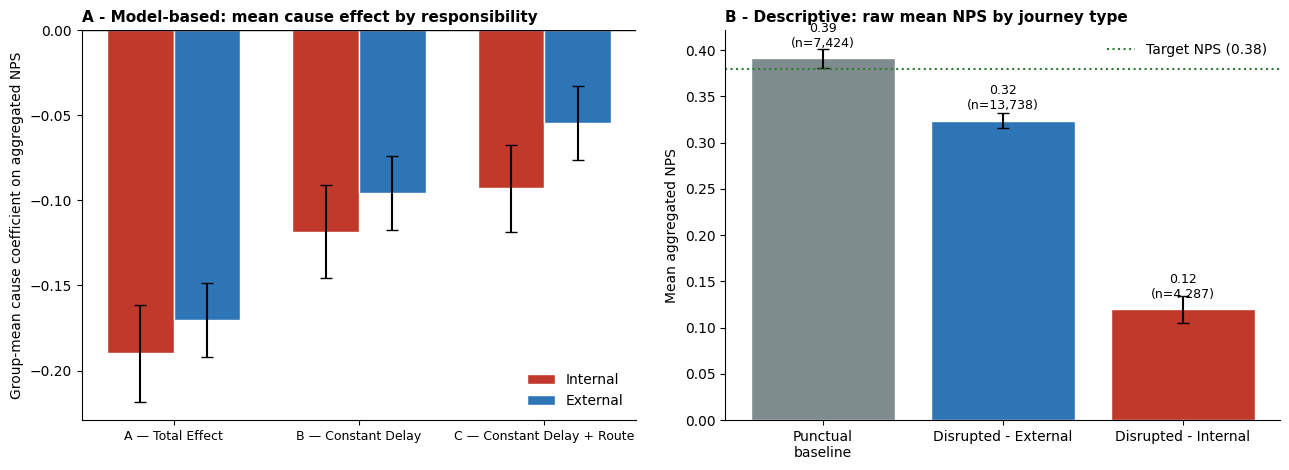

Descriptive group means:
  Punctual baseline            mean NPS = 0.391  (n=7,424)
  Disrupted - External         mean NPS = 0.324  (n=13,738)
  Disrupted - Internal         mean NPS = 0.120  (n=4,287)

Model-based group means and Weiner contrast by spec:
  A — Total Effect: Internal=-0.1899±0.0283  External=-0.1701±0.0217  gap=-0.0199  p=0.2596
  B — Constant Delay: Internal=-0.1183±0.0272  External=-0.0956±0.0216  gap=-0.0227  p=0.1804
  C — Constant Delay + Route: Internal=-0.0928±0.0257  External=-0.0545±0.0216  gap=-0.0383  p=0.01877


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/3230673726.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"gap={float(t.effect):.4f}  p={float(t.pvalue):.4g}")
/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/3230673726.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"gap={float(t.effect):.4f}  p={float(t.pvalue):.4g}")
/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_48505/3230673726.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation.

In [123]:
#internal vs external
def group_mean_ci(fit, members):
    L = pd.Series(0.0, index=fit.params.index); L[members] = 1.0/len(members)
    est = float(L @ fit.params)
    se  = float(np.sqrt(L.values @ fit.cov_params().values @ L.values))
    return est, 1.96*se

specs = [('A — Total Effect', specA),
         ('B — Constant Delay', specB),
         ('C — Constant Delay + Route', specC)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel A 
x = np.arange(len(specs)); wdt = 0.36
for off, grp, col, lbl in [(-wdt/2, internal, '#c0392b', 'Internal'),
                           ( wdt/2, external, '#2e75b6', 'External')]:
    ests, errs = zip(*[group_mean_ci(f, grp) for _, f in specs])
    axes[0].bar(x+off, ests, wdt, yerr=errs, capsize=4, color=col,
                edgecolor='white', label=lbl)
axes[0].axhline(0, color='k', lw=1)

tick_labels = []
for name, f in specs:
    L = pd.Series(0.0, index=f.params.index)
    tick_labels.append(f'{name}')

axes[0].set_xticks(x); axes[0].set_xticklabels(tick_labels, fontsize=9)
axes[0].set_ylabel('Group-mean cause coefficient on aggregated NPS')
axes[0].set_title('A - Model-based: mean cause effect by responsibility',
                  loc='left', fontweight='bold', fontsize=11)
axes[0].legend(frameon=False); axes[0].spines[['top','right']].set_visible(False)

# Panel B 
m2['has_internal'] = m2[internal].sum(axis=1) > 0
m2['has_external'] = m2[external].sum(axis=1) > 0
groups = {
    'Punctual\nbaseline':          m2[~m2['disrupted']],
    'Disrupted - External':  m2[m2['disrupted'] & ~m2['has_internal'] & m2['has_external']],
    'Disrupted - Internal':  m2[m2['disrupted'] & m2['has_internal'] & ~m2['has_external']],
}
names = list(groups)
means = [g['Aggregated NPS'].mean() for g in groups.values()]
sems  = [1.96*g['Aggregated NPS'].sem() for g in groups.values()]
ns    = [len(g) for g in groups.values()]
cols  = ['#7f8c8d', '#2e75b6', '#c0392b']
bars = axes[1].bar(names, means, yerr=sems, capsize=4, color=cols, edgecolor='white')
axes[1].axhline(0.38, color='#2e7d32', ls=':', lw=1.5, label='Target NPS (0.38)')
for b, v, n in zip(bars, means, ns):
    axes[1].text(b.get_x()+b.get_width()/2, v + (0.012 if v >= 0 else -0.025),
                 f'{v:.2f}\n(n={n:,})', ha='center', fontsize=9)
axes[1].set_ylabel('Mean aggregated NPS')
axes[1].set_title('B - Descriptive: raw mean NPS by journey type',
                  loc='left', fontweight='bold', fontsize=11)
axes[1].legend(frameon=False); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print("Descriptive group means:")
for nme, g in groups.items():
    print(f"  {nme.replace(chr(10),' '):28s} mean NPS = {g['Aggregated NPS'].mean():.3f}  (n={len(g):,})")
print("\nModel-based group means and Weiner contrast by spec:")
for name, f in specs:
    int_est, int_ci = group_mean_ci(f, internal)
    ext_est, ext_ci = group_mean_ci(f, external)
    L = pd.Series(0.0, index=f.params.index)
    L[internal] = 1.0/len(internal); L[external] = -1.0/len(external)
    t = f.t_test(L.values)
    print(f"  {name}: Internal={int_est:.4f}±{int_ci:.4f}  External={ext_est:.4f}±{ext_ci:.4f}  "
          f"gap={float(t.effect):.4f}  p={float(t.pvalue):.4g}")